In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from pathlib import Path
 
PROJECT_ROOT = Path.cwd().parent
DOWNSTREAM_CSV = PROJECT_ROOT / "results" / "downstream_scaling" / "summary_downstream_scaling.csv"
PEFT_CSV = PROJECT_ROOT / "results" / "peft" / "summary_peft.csv"
 
# Load data
print("Loading downstream scaling results from:", DOWNSTREAM_CSV)
df_downstream = pd.read_csv(DOWNSTREAM_CSV)
 
print("Loading PEFT results from:", PEFT_CSV)
df_peft = pd.read_csv(PEFT_CSV)
 
print(f"  Downstream: {len(df_downstream)} rows")
print(f"  PEFT:       {len(df_peft)} rows")

Loading downstream scaling results from: /Users/steph/Desktop/ecole/4A/S2/Speech NLP/ml-superb/results/downstream_scaling/summary_downstream_scaling.csv
Loading PEFT results from: /Users/steph/Desktop/ecole/4A/S2/Speech NLP/ml-superb/results/peft/summary_peft.csv
  Downstream: 9 rows
  PEFT:       6 rows


In [82]:
pivot_downstream = df_downstream.pivot(
    index="ssl_model", columns="downstream", values="test_cer"
)[["linear", "transformer_2L", "transformer_6L"]]
 
baseline = df_downstream[df_downstream["downstream"] == "transformer_2L"].set_index("ssl_model")["test_cer"]
lora     = df_peft[df_peft["peft_method"] == "lora"].set_index("ssl_model")["test_cer"]
houlsby  = df_peft[df_peft["peft_method"] == "houlsby"].set_index("ssl_model")["test_cer"]
 
pivot_peft = pd.DataFrame({
    "frozen (baseline)": baseline,
    "LoRA": lora,
    "Houlsby": houlsby,
})

In [83]:
# Params chart 1: downstream
pivot_params_downstream = df_downstream.pivot(
    index="ssl_model", columns="downstream", values="trainable_params_M"
)[["linear", "transformer_2L", "transformer_6L"]]
 
# Params chart 2: peft
baseline_params = df_downstream[df_downstream["downstream"] == "transformer_2L"].set_index("ssl_model")["trainable_params_M"]
lora_params     = df_peft[df_peft["peft_method"] == "lora"].set_index("ssl_model")["trainable_params_M"]
houlsby_params  = df_peft[df_peft["peft_method"] == "houlsby"].set_index("ssl_model")["trainable_params_M"]
 
pivot_params_peft = pd.DataFrame({
    "frozen (baseline)": baseline_params,
    "LoRA": lora_params,
    "Houlsby": houlsby_params,
})
 
print("\n— CER by downstream architecture —")
print(pivot_downstream.to_string())
print("\n— CER by fine-tuning method —")
print(pivot_peft.to_string())


— CER by downstream architecture —
downstream     linear  transformer_2L  transformer_6L
ssl_model                                            
HuBERT-base    0.9023          0.3606          0.3533
mHuBERT-147    0.8220          0.2257          0.2280
wav2vec2-base  0.8318          0.7824          0.3743

— CER by fine-tuning method —
               frozen (baseline)    LoRA  Houlsby
ssl_model                                        
mHuBERT-147               0.2257  0.1868   0.2213
HuBERT-base               0.3606  0.7570   0.3342
wav2vec2-base             0.7824  0.3841   0.3668


In [84]:
MODEL_COLORS = {
    "mHuBERT-147": "#1D9E75",
    "HuBERT-base":  "#534AB7",
    "wav2vec2-base": "#D85A30",
}
MODEL_MARKERS = {
    "mHuBERT-147":  "o",
    "HuBERT-base":  "s",
    "wav2vec2-base": "D",
}
 
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [85]:
def plot_bump(ax, df_cer, title, df_params=None):
    conditions = list(df_cer.columns)
    x = np.arange(len(conditions))
 
    for model in df_cer.index:
        cers   = df_cer.loc[model].values
        color  = MODEL_COLORS.get(model, "#888")
        marker = MODEL_MARKERS.get(model, "o")
 
        ax.plot(x, cers, color=color, linewidth=2.5, zorder=2)
        ax.scatter(x, cers, color=color, marker=marker, s=90, zorder=3, label=model)
 
        for xi, cer_val in zip(x, cers):
            ax.annotate(
                f"{cer_val:.2%}",
                xy=(xi, cer_val),
                xytext=(14, 0),
                textcoords="offset points",
                fontsize=9, color=color, va="center",
            )
 
    # X-axis labels: add mean trainable params under each condition name
    if df_params is not None:
        mean_params = df_params.mean(axis=0)
        xlabels = [f"{cond}\n({mean_params.iloc[i]:.2f}M params)" for i, cond in enumerate(conditions)]
    else:
        xlabels = conditions
 
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, fontsize=11)
    ax.set_ylabel("CER")
    ax.set_title(title, fontsize=14, fontweight="medium", pad=12)
 
    all_vals = df_cer.values.flatten()
    margin = (all_vals.max() - all_vals.min()) * 0.15
    ax.set_ylim(all_vals.min() - margin, all_vals.max() + margin)
 
    ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=0))
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.legend(loc="best", fontsize=10, frameon=False)
 
 
OUTPUT_DIR = PROJECT_ROOT / "results" / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

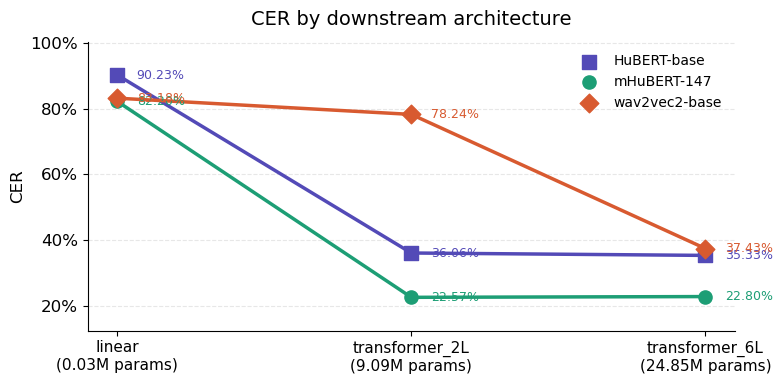

Saved bump_downstream.{pdf,png}


In [90]:
fig1, ax1 = plt.subplots(figsize=(8, 4))
plot_bump(ax1, pivot_downstream, "CER by downstream architecture", df_params=pivot_params_downstream)
fig1.tight_layout()
fig1.savefig(OUTPUT_DIR / "bump_downstream.pdf", bbox_inches="tight")
fig1.savefig(OUTPUT_DIR / "bump_downstream.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved bump_downstream.{pdf,png}")

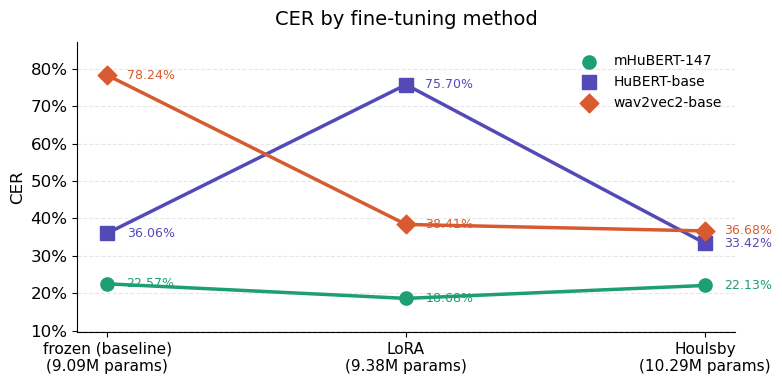

Saved bump_peft.{pdf,png}


In [91]:
fig2, ax2 = plt.subplots(figsize=(8, 4))
plot_bump(ax2, pivot_peft, "CER by fine-tuning method", df_params=pivot_params_peft)
fig2.tight_layout()
fig2.savefig(OUTPUT_DIR / "bump_peft.pdf", bbox_inches="tight")
fig2.savefig(OUTPUT_DIR / "bump_peft.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved bump_peft.{pdf,png}")
